# Version 3.0

Changes:  
1. Added EDA:
    * Imbalance proof: Bar chart
    * Overlay density plots (KDE): Violin plots
    * Correlation heatmap
    * Temporal seasonality line


## Libraries and imports

In [1]:
# Libraries

import numpy as np
import pandas as pd
import requests
import time
from numpy._core.defchararray import zfill
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import classification_report, confusion_matrix, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
from os import scandir
import xgboost as xgb
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Conv1D, BatchNormalization, Activation, Add, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping
import itertools

#import matplotlib.pyplot as plt
import seaborn as sns


## Load data

In [2]:
# Put the exact name of one of your downloaded C5 files here
df_mantenimiento_drenaje = pd.read_csv('../data/raw/MantenimientoDrenaje.csv')
df_mantenimiento_alcantarilla = pd.read_csv('../data/raw/MantenimientoAlcantarilla.csv')
df_fuga_de_agua = pd.read_csv('../data/raw/FugaDeAgua.csv')

## Samples for each dataset

In [3]:
df_mantenimiento_drenaje.head(3)

,id_folio,fecha_solicitud,hora_solicitud,tipo_de_entrada,tema_solicitud,sexo,edad,colonia_solicitud,alcaldia_solicitud,codigo_postal_solicitud,estatus,fecha_concluido,latitud,longitud
0,3212205,2025-04-10,12:04:58,Usuarios SUAC Dependencia,MANTENIMIENTO DRENAJE,Masculino,NaN,NaN,NaN,04380,Cerrado,2025-04-22,NaN,NaN
1,3212681,2025-04-10,12:09:02,Interoperabilidad SACMEX,MANTENIMIENTO DRENAJE,No especificado,NaN,STA CRUZ ATOYAC,14.0,3310,Atendido,2025-07-29,19.367732,-99.161905
2,3212753,2025-04-10,13:18:39,Operador Telefónico LOCATEL,MANTENIMIENTO DRENAJE,No especificado,NaN,NaN,NaN,01400,Atendido,2025-07-29,NaN,NaN


In [4]:
df_mantenimiento_alcantarilla.head(3)

,id_folio,fecha_solicitud,hora_solicitud,tipo_de_entrada,tema_solicitud,sexo,edad,colonia_solicitud,alcaldia_solicitud,codigo_postal_solicitud,estatus,fecha_concluido,latitud,longitud
0,3212212,2025-04-10,11:06:02,Interoperabilidad SACMEX,MANTENIMIENTO DE COLADERA / ALCANTARILLA,No especificado,NaN,CUAUHTEMOC,15.0,6500,Atendido,2025-07-29,19.431219,-99.165014
1,3212320,2025-04-10,12:20:38,Usuarios SUAC Dependencia,MANTENIMIENTO DE COLADERA / ALCANTARILLA,Masculino,53.0,NaN,NaN,10910,Cerrado,2025-05-23,NaN,NaN
2,3212348,2025-04-10,12:24:17,Operador Telefónico LOCATEL,MANTENIMIENTO DE COLADERA / ALCANTARILLA,No especificado,NaN,NaN,NaN,04970,Atendido,2025-08-27,NaN,NaN


In [5]:
df_fuga_de_agua.head(3)

,id_folio,fecha_solicitud,hora_solicitud,tipo_de_entrada,tema_solicitud,sexo,edad,colonia_solicitud,alcaldia_solicitud,codigo_postal_solicitud,estatus,fecha_concluido,latitud,longitud
0,3212221,2025-04-10,11:07:02,Interoperabilidad SACMEX,FUGA DE AGUA,No especificado,NaN,CTM ATZACOALCO,5.0,7090,Cerrado,2025-04-11,19.508236,-99.099069
1,3212235,2025-04-10,11:09:02,Interoperabilidad SACMEX,FUGA DE AGUA,No especificado,NaN,VALLE DEL TEPEYAC,5.0,7740,Cerrado,2025-04-21,19.489393,-99.142925
2,3212239,2025-04-10,12:09:29.085,Portal Ciudadano SUAC,FUGA DE AGUA,Masculino,NaN,LA CASILDA,5.0,07150,Cerrado,2025-06-09,19.556283,-99.123968


## Information about each dataset

In [6]:
df_mantenimiento_alcantarilla.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87539 entries, 0 to 87538
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id_folio                 87539 non-null  int64  
 1   fecha_solicitud          87539 non-null  object 
 2   hora_solicitud           87539 non-null  object 
 3   tipo_de_entrada          87539 non-null  object 
 4   tema_solicitud           87539 non-null  object 
 5   sexo                     69904 non-null  object 
 6   edad                     19487 non-null  float64
 7   colonia_solicitud        45426 non-null  object 
 8   alcaldia_solicitud       45426 non-null  float64
 9   codigo_postal_solicitud  85128 non-null  object 
 10  estatus                  87539 non-null  object 
 11  fecha_concluido          81990 non-null  object 
 12  latitud                  44065 non-null  float64
 13  longitud                 43857 non-null  float64
dtypes: float64(4), int64(1

In [7]:
df_mantenimiento_drenaje.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46445 entries, 0 to 46444
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id_folio                 46445 non-null  int64  
 1   fecha_solicitud          46445 non-null  object 
 2   hora_solicitud           46445 non-null  object 
 3   tipo_de_entrada          46445 non-null  object 
 4   tema_solicitud           46445 non-null  object 
 5   sexo                     39417 non-null  object 
 6   edad                     14786 non-null  float64
 7   colonia_solicitud        25267 non-null  object 
 8   alcaldia_solicitud       25267 non-null  float64
 9   codigo_postal_solicitud  45766 non-null  object 
 10  estatus                  46445 non-null  object 
 11  fecha_concluido          44287 non-null  object 
 12  latitud                  24262 non-null  float64
 13  longitud                 24226 non-null  float64
dtypes: float64(4), int64(1

In [8]:
df_fuga_de_agua.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225130 entries, 0 to 225129
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id_folio                 225130 non-null  int64  
 1   fecha_solicitud          225130 non-null  object 
 2   hora_solicitud           225130 non-null  object 
 3   tipo_de_entrada          225130 non-null  object 
 4   tema_solicitud           225130 non-null  object 
 5   sexo                     198935 non-null  object 
 6   edad                     50057 non-null   float64
 7   colonia_solicitud        137237 non-null  object 
 8   alcaldia_solicitud       137237 non-null  float64
 9   codigo_postal_solicitud  220574 non-null  object 
 10  estatus                  225130 non-null  object 
 11  fecha_concluido          213079 non-null  object 
 12  latitud                  133895 non-null  float64
 13  longitud                 133580 non-null  float64
dtypes: f

## Data Cleansing

Through a helper function, we'll only preserve those fields that helps assign a location (alcaldia) for the incident, either by using the latitude and longitude, the zip code, neighborhood or Municipality.

First we'll only work with the geographical columns

In [9]:
required_columns = [
        'fecha_solicitud',
        'hora_solicitud',
        'tema_solicitud',
        'colonia_solicitud',
        'alcaldia_solicitud',
        'codigo_postal_solicitud',
        'latitud',
        'longitud']


def only_geographical_columns(dataset):
  actual_columns = [col for col in required_columns if col in dataset.columns]
  adjusted_df = dataset[actual_columns].copy()
  return adjusted_df

In [10]:
# Applied to each dataset
df_mantenimiento_drenaje_adjusted = only_geographical_columns(df_mantenimiento_drenaje)
df_mantenimiento_alcantarilla_adjusted = only_geographical_columns(df_mantenimiento_alcantarilla)
df_fuga_de_agua_adjusted = only_geographical_columns(df_fuga_de_agua)

In [11]:
df_mantenimiento_drenaje_adjusted.head(3)


,fecha_solicitud,hora_solicitud,tema_solicitud,colonia_solicitud,alcaldia_solicitud,codigo_postal_solicitud,latitud,longitud
0,2025-04-10,12:04:58,MANTENIMIENTO DRENAJE,NaN,NaN,04380,NaN,NaN
1,2025-04-10,12:09:02,MANTENIMIENTO DRENAJE,STA CRUZ ATOYAC,14.0,3310,19.367732,-99.161905
2,2025-04-10,13:18:39,MANTENIMIENTO DRENAJE,NaN,NaN,01400,NaN,NaN


In [12]:
df_mantenimiento_alcantarilla_adjusted.head(3)

,fecha_solicitud,hora_solicitud,tema_solicitud,colonia_solicitud,alcaldia_solicitud,codigo_postal_solicitud,latitud,longitud
0,2025-04-10,11:06:02,MANTENIMIENTO DE COLADERA / ALCANTARILLA,CUAUHTEMOC,15.0,6500,19.431219,-99.165014
1,2025-04-10,12:20:38,MANTENIMIENTO DE COLADERA / ALCANTARILLA,NaN,NaN,10910,NaN,NaN
2,2025-04-10,12:24:17,MANTENIMIENTO DE COLADERA / ALCANTARILLA,NaN,NaN,04970,NaN,NaN


In [13]:
df_fuga_de_agua_adjusted.head(3)

,fecha_solicitud,hora_solicitud,tema_solicitud,colonia_solicitud,alcaldia_solicitud,codigo_postal_solicitud,latitud,longitud
0,2025-04-10,11:07:02,FUGA DE AGUA,CTM ATZACOALCO,5.0,7090,19.508236,-99.099069
1,2025-04-10,11:09:02,FUGA DE AGUA,VALLE DEL TEPEYAC,5.0,7740,19.489393,-99.142925
2,2025-04-10,12:09:29.085,FUGA DE AGUA,LA CASILDA,5.0,07150,19.556283,-99.123968


And then we'll drop all the entries that have 0 in all those values, since if at least one is present, we can conclude the municipality

In [14]:
def clean_geographicall_nulls(dataset):
  df = dataset.copy()

  # Check the nulls
  text_columns = ['colonia_solicitud', 'alcaldia_solicitud', 'codigo_postal_solicitud']
  for col in text_columns:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace(['','nan','NAN','NA','NaN','Nan','None','none'], np.nan)

  # Check for coordinates
  df['latitud'] = pd.to_numeric(df['latitud'], errors='coerce')
  df['longitud'] = pd.to_numeric(df['longitud'], errors='coerce')

  items_before = len(df)

  # Check if we can identify the municipality using "alcaldia", "colonia" or zip code
  checkIfNull = (
        df['colonia_solicitud'].isna() &
        df['alcaldia_solicitud'].isna() &
        df['codigo_postal_solicitud'].isna() &
        (df['latitud'].isna() | df['longitud'].isna())
    )
  # ~: to keep only those values that we care fore
  clean_dataset = df[~checkIfNull].copy()

  items_after = len(clean_dataset)
  deleted_items = items_before - items_after

  print(f"--- Geo Data Dropped ---")
  print(f"Original records: {items_before}")
  print(f"Deleted records: {deleted_items}")
  print(f"Remaining records: {items_after}")

  return clean_dataset

In [15]:
df_mantenimiento_drenaje_cleaned = clean_geographicall_nulls(df_mantenimiento_drenaje_adjusted)

--- Geo Data Dropped ---
Original records: 46445
Deleted records: 684
Remaining records: 45761


In [16]:
df_mantenimiento_alcantarilla_cleaned = clean_geographicall_nulls(df_mantenimiento_alcantarilla_adjusted)

--- Geo Data Dropped ---
Original records: 87539
Deleted records: 2364
Remaining records: 85175


In [17]:
df_fuga_de_agua_cleaned = clean_geographicall_nulls(df_fuga_de_agua_adjusted)

--- Geo Data Dropped ---
Original records: 225130
Deleted records: 4480
Remaining records: 220650


Next we will fill all the municipalities with the geographical data we have. For this part, if we have either the zip code or the latitude & longitude pairs, we can successfully indentify the municipality.

In [18]:
df_copy = df_mantenimiento_drenaje_cleaned

In [19]:
def fill_municipalities(dataset):

  #Create the new column, empty for the moment
  dataset['alcaldia'] = pd.Series(dtype='object')

  # Dictionary to use in the municipalities
  map_zipcode_municipality = {
        '01': 'ALVARO OBREGON', '02': 'AZCAPOTZALCO', '03': 'BENITO JUAREZ',
        '04': 'COYOACAN', '05': 'CUAJIMALPA DE MORELOS', '06': 'CUAUHTEMOC',
        '07': 'GUSTAVO A. MADERO', '08': 'IZTACALCO', '09': 'IZTAPALAPA',
        '10': 'MAGDALENA CONTRERAS', '11': 'MIGUEL HIDALGO', '12': 'MILPA ALTA',
        '13': 'TLAHUAC', '14': 'TLALPAN', '15': 'VENUSTIANO CARRANZA',
        '16': 'XOCHIMILCO'
    }

  # Get the zipcode first two digits to assign a municipality
  zipcode_prefix = (dataset['codigo_postal_solicitud']
                    .astype(str)
                    .str.extract(r'(\d+)', expand=False)
                    .fillna('')
                    .str.zfill(5)
                    .str[:2]
                  )

  # Map the zipcode using the dictionary
  mapped_municipalities = zipcode_prefix.map(map_zipcode_municipality)

  # Assign them to the new alcaldia column
  dataset.loc[mapped_municipalities.notna(), 'alcaldia'] = mapped_municipalities

  # Statistics
  total = len(dataset)
  municipality_assigned = dataset['alcaldia'].notna().sum()
  municipality_ommited = dataset['alcaldia'].isna().sum()
  print(f"Evaluated records: {total}")
  print(f"Assgined municipality to: {municipality_assigned}")
  print(f"Empty records: {municipality_ommited}") # to be checked with lat/long

  return dataset

In [20]:
df_mantenimiento_alcantarilla_filled = fill_municipalities(df_mantenimiento_alcantarilla_cleaned)

Evaluated records: 85175
Assgined municipality to: 82917
Empty records: 2258


In [21]:
df_mantenimiento_drenaje_filled = fill_municipalities(df_mantenimiento_drenaje_cleaned)

Evaluated records: 45761
Assgined municipality to: 44708
Empty records: 1053


In [22]:
df_fuga_de_agua_filled = fill_municipalities(df_fuga_de_agua_cleaned)

Evaluated records: 220650
Assgined municipality to: 216340
Empty records: 4310


As the final pipeline regarding the municipality, we'll delete all the records that didn't get the municipality

In [23]:
def clean_empty_municipalities(dataset):
  length = len(dataset)

  # drop all records that does not have a municipality assigned
  df_final = dataset.dropna(subset=['alcaldia']).copy()

  final = len(df_final)
  deleted = length - final

  print(f"--- Municipality Dropped ---")
  print(f"Original records: {length}")
  print(f"Deleted records: {deleted}")

  return df_final

In [24]:
df_final_mantenimiento_drenaje = clean_empty_municipalities(df_mantenimiento_drenaje_filled)

--- Municipality Dropped ---
Original records: 45761
Deleted records: 1053


In [25]:
df_final_mantenimiento_alcantarilla = clean_empty_municipalities(df_mantenimiento_alcantarilla_filled)

--- Municipality Dropped ---
Original records: 85175
Deleted records: 2258


In [26]:
df_final_fuga_de_agua = clean_empty_municipalities(df_fuga_de_agua_filled)

--- Municipality Dropped ---
Original records: 220650
Deleted records: 4310


Next will be dropping the variables that will not give usefull information

In [27]:
columns_to_preserve = ['fecha_solicitud', 'hora_solicitud', 'tema_solicitud', 'alcaldia']

# Note: preserve latitud and longitud if can track the location
columns_to_drop = ['colonia_solicitud', 'alcaldia_solicitud', 'codigo_postal_solicitud', 'latitud', 'longitud']

In [28]:
df_final_mantenimiento_drenaje.drop(columns_to_drop, axis=1, inplace=True)
df_final_mantenimiento_drenaje.head(3)

,fecha_solicitud,hora_solicitud,tema_solicitud,alcaldia
0,2025-04-10,12:04:58,MANTENIMIENTO DRENAJE,COYOACAN
1,2025-04-10,12:09:02,MANTENIMIENTO DRENAJE,BENITO JUAREZ
2,2025-04-10,13:18:39,MANTENIMIENTO DRENAJE,ALVARO OBREGON


In [29]:
df_final_mantenimiento_alcantarilla.drop(columns_to_drop, axis=1, inplace=True)
df_final_mantenimiento_alcantarilla.head(3)

,fecha_solicitud,hora_solicitud,tema_solicitud,alcaldia
0,2025-04-10,11:06:02,MANTENIMIENTO DE COLADERA / ALCANTARILLA,CUAUHTEMOC
1,2025-04-10,12:20:38,MANTENIMIENTO DE COLADERA / ALCANTARILLA,MAGDALENA CONTRERAS
2,2025-04-10,12:24:17,MANTENIMIENTO DE COLADERA / ALCANTARILLA,COYOACAN


In [30]:
df_final_fuga_de_agua.drop(columns_to_drop, axis=1, inplace=True)
df_final_fuga_de_agua.head(3)

,fecha_solicitud,hora_solicitud,tema_solicitud,alcaldia
0,2025-04-10,11:07:02,FUGA DE AGUA,GUSTAVO A. MADERO
1,2025-04-10,11:09:02,FUGA DE AGUA,GUSTAVO A. MADERO
2,2025-04-10,12:09:29.085,FUGA DE AGUA,GUSTAVO A. MADERO


Merging the 3 datasets into a unique dataset containing all the incidents

In [31]:
df_incidents = pd.concat([
    df_final_mantenimiento_drenaje,
    df_final_mantenimiento_alcantarilla,
    df_final_fuga_de_agua
], ignore_index=True)

df_incidents

,fecha_solicitud,hora_solicitud,tema_solicitud,alcaldia
0,2025-04-10,12:04:58,MANTENIMIENTO DRENAJE,COYOACAN
1,2025-04-10,12:09:02,MANTENIMIENTO DRENAJE,BENITO JUAREZ
2,2025-04-10,13:18:39,MANTENIMIENTO DRENAJE,ALVARO OBREGON
3,2025-04-10,12:29:07,MANTENIMIENTO DRENAJE,ALVARO OBREGON
4,2025-04-10,13:41:22.882,MANTENIMIENTO DRENAJE,GUSTAVO A. MADERO
...,...,...,...,...
343960,2025-03-02,07:30:01,FUGA DE AGUA,CUAUHTEMOC
343961,2025-03-02,07:32:09,FUGA DE AGUA,ALVARO OBREGON
343962,2025-03-02,07:38:20,FUGA DE AGUA,ALVARO OBREGON
343963,2025-03-02,07:44:02,FUGA DE AGUA,CUAUHTEMOC


We'll round down the minutes and hours to mantain only records for each hour

In [32]:
# Round down time
def round_down_time(dataset):
    df = dataset.copy()

    time_serie = pd.to_datetime(df['fecha_solicitud'] + ' ' + df['hora_solicitud'].astype(str), errors='coerce')
    df['time'] = time_serie

    # truncate time
    df['time'] = df['time'].dt.floor('h')

    columns_to_drop = ['fecha_solicitud', 'hora_solicitud']
    df.drop(columns_to_drop, axis=1, inplace=True)

    return df

In [33]:
df_incidents_rounded = round_down_time(df_incidents)
df_incidents_rounded.head(3)

,tema_solicitud,alcaldia,time
0,MANTENIMIENTO DRENAJE,COYOACAN,2025-04-10 12:00:00
1,MANTENIMIENTO DRENAJE,BENITO JUAREZ,2025-04-10 12:00:00
2,MANTENIMIENTO DRENAJE,ALVARO OBREGON,2025-04-10 13:00:00


We'll also add a new column to be a flag, all the rows inside the incidents dataframe will have a one, meaning an incident was reported. When merging the full dataset, if no incident was registered, it will have a 0 value.

In [34]:
def add_incident_flag(dataset):
  df = dataset.copy()
  initial_rows = len(dataset)

  # group by incidents, if same happens, increase severity
  df_compressed = df.groupby(['alcaldia', 'time', 'tema_solicitud']).size().reset_index(name='severidad')

  # Compress exact hour incidents, if same type happens, then increase the severity
  df_compressed['incident'] = 1

  final_rows = len(df_compressed)
  duplicates_crushed = initial_rows - final_rows

  print(f"Redundant duplicates compressed: {duplicates_crushed:,}")
  print(f"Clean, unique incident hours: {final_rows:,}")

  return df_compressed

In [35]:
df_final_incidents = add_incident_flag(df_incidents_rounded)
df_final_incidents.head(3)

Redundant duplicates compressed: 172,918
Clean, unique incident hours: 171,047


,alcaldia,time,tema_solicitud,severidad,incident
0,ALVARO OBREGON,2019-06-02 13:00:00,FUGA DE AGUA,1,1
1,ALVARO OBREGON,2019-06-03 09:00:00,FUGA DE AGUA,2,1
2,ALVARO OBREGON,2019-06-03 11:00:00,FUGA DE AGUA,2,1


Next, using Open-Meteo API we'll get all the telemetry data for weather and other climatological conditions.

Open meteo reference:

> <a href="https://open-meteo.com/">
	Weather data by Open-Meteo.com
</a>



In [36]:
df_weather_master = pd.read_csv('../data/raw/CdmxWeather.csv') 
print("\nAssembling the Master Matrix...")
#df_weather_master = pd.concat(dfs_weather, ignore_index=True)

# Convert the string time to a real mathematical datetime object
df_weather_master['time'] = pd.to_datetime(df_weather_master['time'])

print(f"\n--- TELEMETRY REPORT ---")
print(f"Total rows fetched: {len(df_weather_master)}")


Assembling the Master Matrix...

--- TELEMETRY REPORT ---
Total rows fetched: 993792


Let's now merge the 2 main datasets into a complete dataset to use it to train the model.

In [37]:
def merging_datasets(df_weather, df_incidents):

  # We first compare that both time columns are mathematically equals
  df_weather['time'] = pd.to_datetime(df_weather['time'])
  df_incidents['time'] = pd.to_datetime(df_incidents['time'])

  # We also do the same approach with alcaldia columns
  df_weather['alcaldia'] = df_weather['alcaldia'].astype(str).str.strip().str.upper()
  df_incidents['alcaldia'] = df_incidents['alcaldia'].astype(str).str.strip().str.upper()

  filas_clima_original = len(df_weather)

  # merging datasets
  df_merged = pd.merge(df_weather, df_incidents, on=['alcaldia', 'time'], how='left')

  # We populate the empty records that have no incidents and severity
  # for incident, if 0 was a regular day
  df_merged['incident'] = df_merged['incident'].fillna(0).astype(int)

  # for severity, 0 if nothing happens
  df_merged['severidad'] = df_merged['severidad'].fillna(0).astype(int)

  # for incident type, create 'without incident'
  df_merged['tema_solicitud'] = df_merged['tema_solicitud'].fillna('SIN INCIDENTE')

  return df_merged

In [38]:
dataset_final = merging_datasets(df_weather_master, df_final_incidents)

In [39]:
dataset_final.head(5)

,time,temperature_2m,precipitation,relative_humidity_2m,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_moisture_28_to_100cm,runoff,et0_fao_evapotranspiration,wind_speed_10m,wind_gusts_10m,alcaldia,tema_solicitud,severidad,incident
0,2019-01-01 00:00:00,8.4,0.0,73,0.123,0.138,0.145,NaN,0.00,4.6,15.5,ALVARO OBREGON,SIN INCIDENTE,0,0
1,2019-01-01 01:00:00,8.0,0.0,70,0.123,0.138,0.145,NaN,0.00,4.8,13.7,ALVARO OBREGON,SIN INCIDENTE,0,0
2,2019-01-01 02:00:00,7.2,0.0,71,0.123,0.138,0.145,NaN,0.00,5.4,15.8,ALVARO OBREGON,SIN INCIDENTE,0,0
3,2019-01-01 03:00:00,6.4,0.0,65,0.123,0.138,0.145,NaN,0.01,6.9,19.1,ALVARO OBREGON,SIN INCIDENTE,0,0
4,2019-01-01 04:00:00,5.7,0.0,58,0.123,0.138,0.145,NaN,0.01,5.9,19.4,ALVARO OBREGON,SIN INCIDENTE,0,0


## Feature engineering

In [40]:
def feature_engineering(dataset):

  df = dataset.copy()

  # Sort time series chronologically by municipality
  df = df.sort_values(by=['alcaldia', 'time']).reset_index(drop=True)

  # Temporal deconstruction from YYYY-DD-MM HH:MM:SS into 4 columns
  df['mes'] = df['time'].dt.month
  df['dia_semana'] = df['time'].dt.dayofweek # Monday=0, Sunday=6
  df['hora_del_dia'] = df['time'].dt.hour
  df['es_fin_de_semana'] = df['dia_semana'].apply(lambda x: 1 if x >= 5 else 0)

  # Creating rolling windows to take accumulate precipitation for 3, 6 12 and 24 hours
  # Variable that accumulate rain
  col_to_sum = ['precipitation']

  # Variables that saturate (Soil Moisture, Humidity)
  cols_to_mean = ['soil_moisture_0_to_7cm', 'soil_moisture_7_to_28cm', 'relative_humidity_2m']

  # Time rolling windows
  time_windows = [3, 6, 12, 24]

  for w in time_windows:
    for col in col_to_sum:
      if col in df.columns:
        df[f'{col}_sum_{w}h'] = df.groupby('alcaldia')[col].transform(lambda x: x.rolling(window=w, min_periods=1).sum())

    for col in cols_to_mean:
      if col in df.columns:
        df[f'{col}_mean_{w}h'] = df.groupby('alcaldia')[col].transform(lambda x: x.rolling(window=w, min_periods=1).mean())

  # Dropping the first 24 hours of data per municipality to calculate well the window
  df_final = df[df.groupby('alcaldia').cumcount() >= 24].reset_index(drop=True)

  print(f"Original rows: {len(df)}")
  print(f"Final rows after burn-in drop: {len(df_final)}")
  return df_final

In [41]:
df_ml = feature_engineering(dataset_final)

Original rows: 1018852
Final rows after burn-in drop: 1018468


In [42]:
df_ml.head(3)

,time,temperature_2m,precipitation,relative_humidity_2m,soil_moisture_0_to_7cm,soil_moisture_7_to_28cm,soil_moisture_28_to_100cm,runoff,et0_fao_evapotranspiration,wind_speed_10m,...,soil_moisture_7_to_28cm_mean_6h,relative_humidity_2m_mean_6h,precipitation_sum_12h,soil_moisture_0_to_7cm_mean_12h,soil_moisture_7_to_28cm_mean_12h,relative_humidity_2m_mean_12h,precipitation_sum_24h,soil_moisture_0_to_7cm_mean_24h,soil_moisture_7_to_28cm_mean_24h,relative_humidity_2m_mean_24h
0,2019-01-02 00:00:00,12.1,0.0,44,0.125,0.138,0.145,NaN,0.00,1.4,...,0.138,35.500000,0.0,0.124583,0.138,25.666667,0.0,0.124083,0.138,38.458333
1,2019-01-02 01:00:00,11.0,0.0,50,0.125,0.138,0.145,NaN,0.00,0.0,...,0.138,40.166667,0.0,0.124667,0.138,28.250000,0.0,0.124167,0.138,37.625000
2,2019-01-02 02:00:00,10.1,0.0,45,0.125,0.138,0.145,NaN,0.01,3.6,...,0.138,43.666667,0.0,0.124750,0.138,30.750000,0.0,0.124250,0.138,36.541667


In [43]:
def split_data(df, split_date='2025-01-01'):

  # One-Hot Encoding the categorical variable for alcaldia
  df_encoded = pd.get_dummies(df, columns=['alcaldia'], drop_first=False, dtype=int)

  # Slicing using the split date
  df_encoded['time'] = pd.to_datetime(df_encoded['time'])

  # Masks to split train and test
  train_mask = df_encoded['time'] < split_date
  test_mask = df_encoded['time'] >= split_date

  # make the splitting of the data
  df_train = df_encoded[train_mask].copy()
  df_test = df_encoded[test_mask].copy()

  # Delete features from train
  columns_to_drop = ['incident', 'time', 'severidad', 'tema_solicitud','runoff']

  X_train = df_train.drop(columns=columns_to_drop)
  y_train = df_train['incident']

  X_test = df_test.drop(columns=columns_to_drop)
  y_test = df_test['incident']

  return X_train, X_test, y_train, y_test


In [44]:
X_train, X_test, y_train, y_test = split_data(df_ml)

Use StandardScaler to normalize the values

In [45]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Create sequences for LTSM. We use window_size=24 because the data is hourly.

In [46]:
def create_sequences(X, y, window_size):
    X_seq = []
    y_seq = []

    for i in range(window_size, len(X)):
        X_seq.append(X[i-window_size:i])
        y_seq.append(y.iloc[i])

    return np.array(X_seq), np.array(y_seq)

In [47]:
window_size = 24
X_train_tcn, y_train_tcn = create_sequences(X_train_scaled, y_train, window_size)
X_test_tcn, y_test_tcn = create_sequences(X_test_scaled, y_test, window_size)

print(X_train_tcn.shape)
print(y_train_tcn.shape)

(854287, 24, 45)
(854287,)


## EDA

--- GENERATING EDA FIG 1: TARGET DISTRIBUTION ---


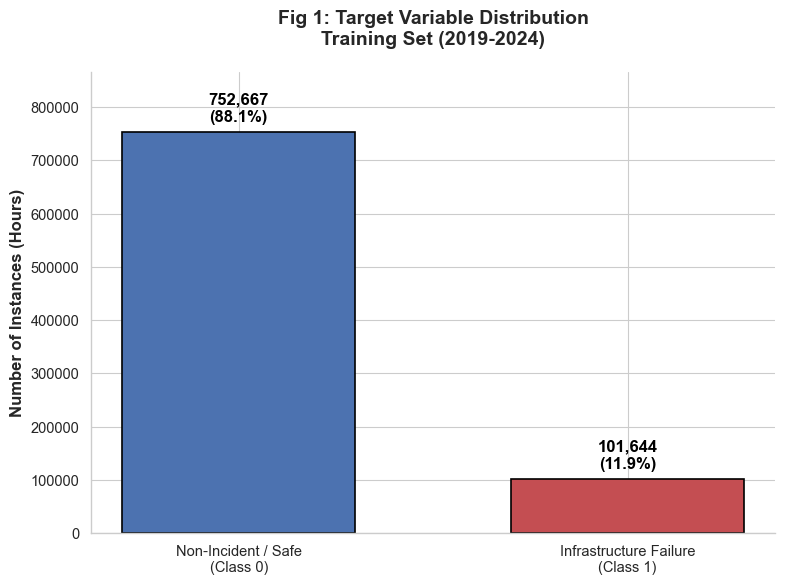

In [48]:

def plot_target_distribution(y_train):
    """
    Generates a publication-ready bar chart showing the severe class
    imbalance in the training dataset (2019-2024).
    """
    print("--- GENERATING EDA FIG 1: TARGET DISTRIBUTION ---")

    # 1. Set a clean, academic visual style (no distracting backgrounds)
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

    # 2. Calculate the raw counts and the percentages
    counts = y_train.value_counts().sort_index()
    percentages = y_train.value_counts(normalize=True).sort_index() * 100

    # 3. Initialize the canvas
    fig, ax = plt.subplots(figsize=(8, 6))

    # 4. Define our labels and professional colors
    labels = ['Non-Incident / Safe\n(Class 0)', 'Infrastructure Failure\n(Class 1)']
    colors = ['#4C72B0', '#C44E52'] # Muted Blue and Muted Red

    # 5. Plot the bars
    bars = ax.bar(labels, counts, color=colors, edgecolor='black', linewidth=1.2, width=0.6)

    # 6. Add the dual-annotations (Count + Percentage) right above the bars
    for bar, count, percent in zip(bars, counts, percentages):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2,
                height + (max(counts) * 0.02), # Slight padding above the bar
                f'{count:,}\n({percent:.1f}%)',
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

    # 7. Formatting and Titles
    ax.set_title('Fig 1: Target Variable Distribution\nTraining Set (2019-2024)',
                 fontsize=14, pad=20, fontweight='bold')
    ax.set_ylabel('Number of Instances (Hours)', fontsize=12, fontweight='bold')
    ax.set_ylim(0, max(counts) * 1.15) # Add 15% headroom for the text annotations

    # Remove the top and right borders for a cleaner look
    sns.despine()

    # 8. Save the figure at publication quality (300 DPI)
    plt.tight_layout()
    plt.savefig('EDA_1_Target_Distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

# --- EXECUTION ---
# Run this right after your split_data() function
plot_target_distribution(y_train)

We need to calculate class weights in order to train the model using balanced weights, compensating for the class imbalance between flood and non-flood events.

In [49]:
classes = np.unique(y_train_tcn)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_tcn
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(0.5675247095900713), np.int64(1): np.float64(4.202348392428476)}


## Model creation

In [50]:
def residual_tcn_block(x, filters, kernel_size, dilation_rate, dropout_rate):

    # Save the original input for the residual connection
    shortcut = x

    # Apply a causal temporal convolution to learn temporal patterns
    x = Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        dilation_rate=dilation_rate,
        padding="causal"
    )(x)

    # Normalize activations to stabilize training
    x = BatchNormalization()(x)

    # Apply non-linearity to learn complex relationships
    x = Activation("relu")(x)

    # Randomly deactivate neurons to reduce overfitting
    x = Dropout(dropout_rate)(x)

    # Apply a second temporal convolution for deeper feature extraction
    x = Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        dilation_rate=dilation_rate,
        padding="causal"
    )(x)

    # Normalize the second convolution output
    x = BatchNormalization()(x)

    # Adjust shortcut dimensions if the number of channels changed
    if shortcut.shape[-1] != filters:
        shortcut = Conv1D(
            filters=filters,
            kernel_size=1,
            padding="same"
        )(shortcut)

    # Combine learned features with the original input using a residual connection
    x = Add()([x, shortcut])

    # Apply final activation after the residual merge
    x = Activation("relu")(x)

    # Return the transformed temporal representation
    return x

In [51]:
def build_tcn_model(
    window_size,
    n_features,
    filters=64,
    kernel_size=3,
    dropout_rate=0.3,
    dense_units=32
):

    # Define the input shape as (timesteps, features)
    inputs = Input(shape=(window_size, n_features))

    # Learn short-term temporal patterns using dilation rate 1
    x = residual_tcn_block(
        inputs,
        filters=filters,
        kernel_size=kernel_size,
        dilation_rate=1,
        dropout_rate=dropout_rate
    )

    # Learn medium-range temporal dependencies using dilation rate 2
    x = residual_tcn_block(
        x,
        filters=filters,
        kernel_size=kernel_size,
        dilation_rate=2,
        dropout_rate=dropout_rate
    )

    # Learn longer temporal dependencies using dilation rate 4
    x = residual_tcn_block(
        x,
        filters=filters,
        kernel_size=kernel_size,
        dilation_rate=4,
        dropout_rate=dropout_rate
    )

    # Compress the temporal sequence into a single feature vector
    x = GlobalAveragePooling1D()(x)

    # Learn high-level non-linear combinations of temporal features
    x = Dense(dense_units, activation="relu")(x)

    # Apply dropout regularization before the final prediction
    x = Dropout(dropout_rate / 2)(x)

    # Output the probability of a flood event
    outputs = Dense(1, activation="sigmoid")(x)

    # Build the complete TCN model
    model = Model(inputs, outputs)

    # Configure training settings for binary classification
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    # Return the compiled model
    return model

In [52]:
n_features = X_train_tcn.shape[2]

tcn_model = build_tcn_model(
    window_size=window_size,
    n_features=n_features,
    filters=64,
    kernel_size=3,
    dropout_rate=0.3,
    dense_units=32
)

tcn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 45)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 24, 64)    │      8,704 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 24, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 24, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 24, 64)    │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 24, 64)    │     12,352 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 24, 64)    │      2,944 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 24, 64)    │          0 │ batch_normalizat… │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 24, 64)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 24, 64)    │     12,352 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 24, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 24, 64)    │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 24, 64)    │     12,352 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 64)    │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 24, 64)    │          0 │ batch_normalizat… │
│                     │                   │            │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 24, 64)    │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 24, 64)    │     12,352 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 77,057 (301.00 KB)

 Trainable params: 76,289 (298.00 KB)

 Non-trainable params: 768 (3.00 KB)

Train the model

In [53]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = tcn_model.fit(
    X_train_tcn,
    y_train_tcn,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)

Epoch 1/20
10679/10679 ━━━━━━━━━━━━━━━━━━━━ 105s 10ms/step - accuracy: 0.7458 - loss: 0.4741 - val_accuracy: 0.8226 - val_loss: 0.3888
Epoch 2/20
10679/10679 ━━━━━━━━━━━━━━━━━━━━ 97s 9ms/step - accuracy: 0.7630 - loss: 0.4533 - val_accuracy: 0.7225 - val_loss: 0.4925
Epoch 3/20
10679/10679 ━━━━━━━━━━━━━━━━━━━━ 96s 9ms/step - accuracy: 0.7653 - loss: 0.4466 - val_accuracy: 0.7448 - val_loss: 0.4841
Epoch 4/20
10679/10679 ━━━━━━━━━━━━━━━━━━━━ 96s 9ms/step - accuracy: 0.7674 - loss: 0.4423 - val_accuracy: 0.7088 - val_loss: 0.5199
Epoch 5/20
10679/10679 ━━━━━━━━━━━━━━━━━━━━ 98s 9ms/step - accuracy: 0.7685 - loss: 0.4396 - val_accuracy: 0.6863 - val_loss: 0.5527
Epoch 6/20
10679/10679 ━━━━━━━━━━━━━━━━━━━━ 97s 9ms/step - accuracy: 0.7708 - loss: 0.4371 - val_accuracy: 0.7383 - val_loss: 0.4862


Evaluate the model

In [54]:
y_scores_tcn = tcn_model.predict(X_test_tcn).ravel()

threshold = 0.40
y_pred_tcn = (y_scores_tcn >= threshold).astype(int)

print(classification_report(y_test_tcn, y_pred_tcn))
print("PR-AUC:", average_precision_score(y_test_tcn, y_scores_tcn))

5130/5130 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
              precision    recall  f1-score   support

           0       0.80      0.82      0.81    105180
           1       0.67      0.64      0.66     58953

    accuracy                           0.76    164133
   macro avg       0.74      0.73      0.73    164133
weighted avg       0.76      0.76      0.76    164133

PR-AUC: 0.726553817800239


5130/5130 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step


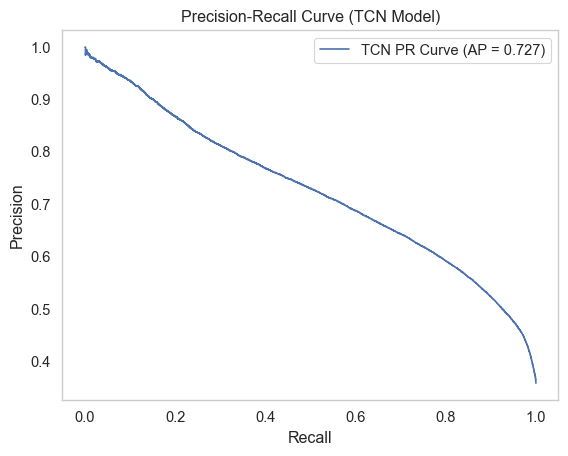

In [55]:
# Obtener probabilidades del modelo TCN
y_scores_tcn = tcn_model.predict(X_test_tcn).ravel()

# Calcular precision-recall
precision_tcn, recall_tcn, thresholds_tcn = precision_recall_curve(
    y_test_tcn,
    y_scores_tcn
)

# Calcular PR-AUC / Average Precision
ap_tcn = average_precision_score(y_test_tcn, y_scores_tcn)

# Graficar
plt.figure()
plt.plot(recall_tcn, precision_tcn, label=f"TCN PR Curve (AP = {ap_tcn:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (TCN Model)")
plt.legend()
plt.grid()
plt.show()

In [56]:
threshold = 0.40
y_pred_tcn = (y_scores_tcn >= threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test_tcn, y_pred_tcn).ravel()

print(f"True negatives (predicted safe, was safe): {tn:,}")
print(f"False Positive (predicted incident, was safe): {fp:,} false alarms)")
print(f"False Negatives (predicted safe, was an incident) {fn:,} <- This is the danger, must be low")
print(f"True Positives (predicted incident, was an incident): {tp:,}")

True negatives (predicted safe, was safe): 86,490
False Positive (predicted incident, was safe): 18,690 false alarms)
False Negatives (predicted safe, was an incident) 21,135 <- This is the danger, must be low
True Positives (predicted incident, was an incident): 37,818


In [57]:
def optimize_recall_tcn(modelo, X_test_tcn, y_test_tcn, new_threshold=0.40):

    # The TCN already outputs the probability of class 1 because
    # the final layer uses Dense(1, activation="sigmoid")
    probabilities = modelo.predict(X_test_tcn).ravel()

    # Apply new threshold
    adjusted_predictions = (probabilities >= new_threshold).astype(int)

    print("New Threshold report:")
    print(classification_report(y_test_tcn, adjusted_predictions))

    # Extract confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test_tcn, adjusted_predictions).ravel()

    print("Adjusted Confusion matrix")
    print(f"True negatives: {tn:,}")
    print(f"False Positive (Falsas Alarmas): {fp:,} <- Subirán (Es el costo)")
    print(f"False Negatives  (EL PELIGRO): {fn:,} <- DEBEN BAJAR")
    print(f"True Positives (SALVADOS): {tp:,} <- DEBEN SUBIR")

In [58]:
predicciones_optimas = optimize_recall_tcn(tcn_model, X_test_tcn, y_test_tcn, new_threshold=0.40)

5130/5130 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
New Threshold report:
              precision    recall  f1-score   support

           0       0.80      0.82      0.81    105180
           1       0.67      0.64      0.66     58953

    accuracy                           0.76    164133
   macro avg       0.74      0.73      0.73    164133
weighted avg       0.76      0.76      0.76    164133

Adjusted Confusion matrix
True negatives: 86,490
False Positive (Falsas Alarmas): 18,690 <- Subirán (Es el costo)
False Negatives  (EL PELIGRO): 21,135 <- DEBEN BAJAR
True Positives (SALVADOS): 37,818 <- DEBEN SUBIR


In [ ]:
# Function to tune TCN hyperparameters using automatic validation split
def hyperparameter_tuning_tcn(
    X_train_tcn,
    y_train_tcn,
    window_size,
    threshold=0.40
):

    # Get number of input features per timestep
    n_features = X_train_tcn.shape[2]

    # Define validation size for metric calculation
    val_size = int(len(X_train_tcn) * 0.2)

    # Extract automatic validation subset
    X_val_tcn = X_train_tcn[-val_size:]
    y_val_tcn = y_train_tcn[-val_size:]

    # Define hyperparameter search space
    parameters_space = {
        "filters": [32, 64],
        "dense_units": [16, 32],
        "dropout_rate": [0.2, 0.3],
        "batch_size": [64]
    }

    # Generate all hyperparameter combinations
    combinations = list(itertools.product(
        parameters_space["filters"],
        parameters_space["dense_units"],
        parameters_space["dropout_rate"],
        parameters_space["batch_size"]
    ))

    # Store tuning results
    results = []

    # Start execution timer
    start = time.time()

    # Train one model per hyperparameter combination
    for filters, dense_units, dropout_rate, batch_size in combinations:

        # Print current configuration
        print(
            f"Training: TCN={filters}, "
            f"Dense={dense_units}, "
            f"Dropout={dropout_rate}, "
            f"Batch={batch_size}"
        )

        # Build model with current hyperparameters
        model = build_tcn_model(
            window_size=window_size,
            n_features=n_features,
            filters=filters,
            kernel_size=3,
            dense_units=dense_units,
            dropout_rate=dropout_rate
        )

        # Stop training when validation loss stops improving
        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )

        # Train model using automatic validation split
        history = model.fit(
            X_train_tcn,
            y_train_tcn,
            validation_split=0.2,
            epochs=20,
            batch_size=batch_size,
            callbacks=[early_stop],
            class_weight=class_weights,
            shuffle=False,
            verbose=0
        )

        # Predict probabilities on validation subset
        probabilities = model.predict(X_val_tcn).ravel()

        # Convert probabilities into binary predictions
        predictions = (probabilities >= threshold).astype(int)

        # Compute validation metrics
        pr_auc = average_precision_score(y_val_tcn, probabilities)
        recall = recall_score(y_val_tcn, predictions, zero_division=0)
        f1 = f1_score(y_val_tcn, predictions, zero_division=0)

        # Save current experiment results
        results.append({
            "filters": filters,
            "dense_units": dense_units,
            "dropout_rate": dropout_rate,
            "batch_size": batch_size,
            "epochs_trained": len(history.history["loss"]),
            "pr_auc": pr_auc,
            "recall": recall,
            "f1": f1,
            "model": model
        })

    # End execution timer
    end = time.time()

    # Sort results by validation PR-AUC
    results = sorted(results, key=lambda x: x["pr_auc"], reverse=True)

    # Select best configuration
    best_result = results[0]

    # Convert execution time to minutes
    minutos = (end - start) / 60

    # Print tuning summary
    print(f"Tiempo de ejecución: {minutos:.2f} minutos")
    print("LA ARQUITECTURA GANADORA ES:")
    print(f"-> filters: {best_result['filters']}")
    print(f"-> dense_units: {best_result['dense_units']}")
    print(f"-> dropout_rate: {best_result['dropout_rate']}")
    print(f"-> batch_size: {best_result['batch_size']}")
    print(f"-> epochs_trained: {best_result['epochs_trained']}")
    print(f"\nMejor Score (PR-AUC) en validación: {best_result['pr_auc']:.4f}")
    print(f"Recall en validación: {best_result['recall']:.4f}")
    print(f"F1 en validación: {best_result['f1']:.4f}")

    # Return best model and tuning results
    return best_result["model"], results

In [ ]:
# Perform TCN hyperparameter tuning using validation performance
hyperparameterized_tcn_model, tcn_tuning_results = hyperparameter_tuning_tcn(
    X_train_tcn,
    y_train_tcn,
    window_size=window_size,
    threshold=0.40
)

Training: TCN=32, Dense=16, Dropout=0.2, Batch=64
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
Training: TCN=32, Dense=16, Dropout=0.3, Batch=64
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
Training: TCN=32, Dense=32, Dropout=0.2, Batch=64
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
Training: TCN=32, Dense=32, Dropout=0.3, Batch=64
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
Training: TCN=64, Dense=16, Dropout=0.2, Batch=64
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
Training: TCN=64, Dense=16, Dropout=0.3, Batch=64
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
Training: TCN=64, Dense=32, Dropout=0.2, Batch=64
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
Training: TCN=64, Dense=32, Dropout=0.3, Batch=64
5340/5340 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
Tiempo de ejecución: 75.66 minutos
LA ARQUITECTURA GANADORA ES:
-> filters: 64
-> dense_units: 32
-> dropout_rate: 0.3
-> batch_size: 64
-> epochs_trained: 9

Mejor Score (PR-AUC) en validación: 0.3638
Recall en validación: 0.6356
F1 en validación: 0.4

In [61]:
def final_model_evaluation_tcn(modelo_campeon, X_test_tcn, y_test_tcn, umbral=0.40):
    print("--- INICIANDO EVALUACIÓN FINAL TCN SOBRE EL FUTURO (2025) ---")

    # El TCN ya devuelve probabilidades por la capa sigmoid
    probabilidades = modelo_campeon.predict(X_test_tcn).ravel()

    # Aplicamos el umbral estratégico
    predicciones_finales = (probabilidades >= umbral).astype(int)

    print(f"\nREPORTE DE RENDIMIENTO (UMBRAL: {umbral * 100:.0f}%)")
    print("=" * 50)
    print(classification_report(y_test_tcn, predicciones_finales))

    # Matriz de confusión final
    tn, fp, fn, tp = confusion_matrix(y_test_tcn, predicciones_finales).ravel()

    print("\nMATRIZ DE CONFUSIÓN DEFINITIVA:")
    print(f"Verdaderos Negativos (Días/Horas Pacíficas): {tn:,}")
    print(f"Falsos Positivos (Falsas Alarmas): {fp:,}")
    print(f"Falsos Negativos (Desastres Omitidos): {fn:,}")
    print(f"Verdaderos Positivos (Desastres Prevenidos): {tp:,}")

    # Métricas de negocio
    recall_final = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision_final = tp / (tp + fp) if (tp + fp) > 0 else 0

    print("\nMÉTRICAS DE NEGOCIO (PROTECCIÓN CIVIL):")
    print(f"-> Tasa de Captura (Recall): {recall_final * 100:.1f}% de las inundaciones fueron detectadas.")
    print(f"-> Precisión de Alarma: {precision_final * 100:.1f}% de las alertas fueron reales.")

    return {
        "threshold": umbral,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "recall": recall_final,
        "precision": precision_final
    }

In [62]:
tcn_final_results = final_model_evaluation_tcn(
    hyperparameterized_tcn_model,
    X_test_tcn,
    y_test_tcn,
    umbral=0.40
)

--- INICIANDO EVALUACIÓN FINAL TCN SOBRE EL FUTURO (2025) ---
5130/5130 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step

REPORTE DE RENDIMIENTO (UMBRAL: 40%)
              precision    recall  f1-score   support

           0       0.83      0.79      0.81    105180
           1       0.66      0.70      0.68     58953

    accuracy                           0.76    164133
   macro avg       0.74      0.75      0.75    164133
weighted avg       0.77      0.76      0.76    164133


MATRIZ DE CONFUSIÓN DEFINITIVA:
Verdaderos Negativos (Días/Horas Pacíficas): 83,540
Falsos Positivos (Falsas Alarmas): 21,640
Falsos Negativos (Desastres Omitidos): 17,409
Verdaderos Positivos (Desastres Prevenidos): 41,544

MÉTRICAS DE NEGOCIO (PROTECCIÓN CIVIL):
-> Tasa de Captura (Recall): 70.5% de las inundaciones fueron detectadas.
-> Precisión de Alarma: 65.8% de las alertas fueron reales.


5130/5130 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step


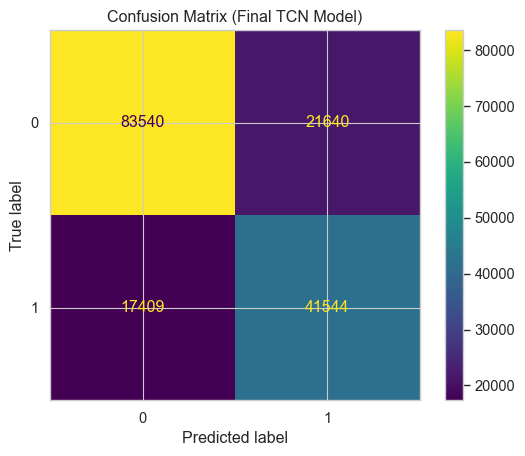

In [63]:
y_pred_final_tcn = (
    hyperparameterized_tcn_model
    .predict(X_test_tcn)
    .ravel() >= 0.40
).astype(int)

ConfusionMatrixDisplay.from_predictions(
    y_test_tcn,
    y_pred_final_tcn
)

plt.title("Confusion Matrix (Final TCN Model)")
plt.show()

A diferencia de XGBoost, los modelos LSTM no proporcionan métricas directas de importancia de variables debido a sus representaciones temporales distribuidas.

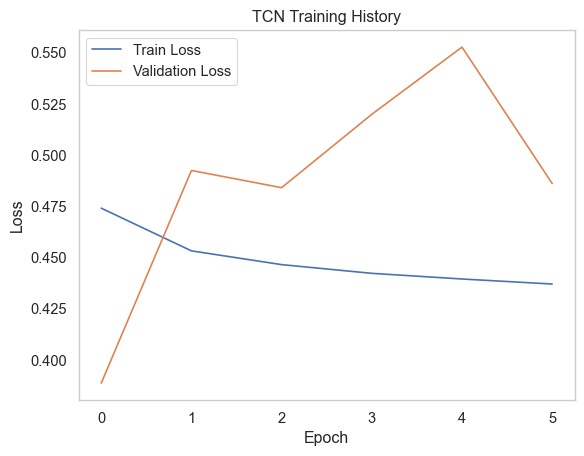

In [ ]:
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("TCN Training History")

plt.legend()
plt.grid()

plt.show()

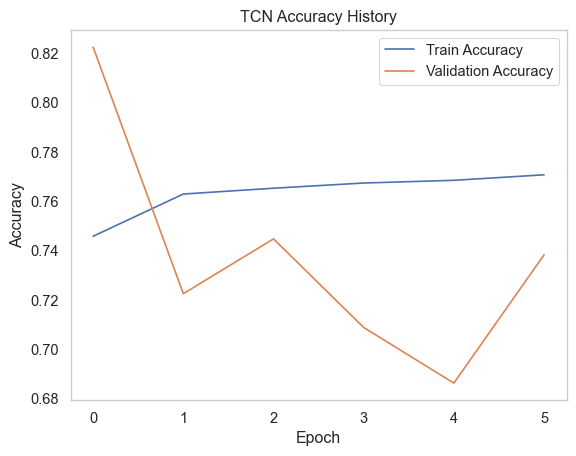

In [65]:
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("TCN Accuracy History")

plt.legend()
plt.grid()

plt.show()